In [1]:
# Importing libraries

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset

df = pd.read_csv("loan_approval_dataset.csv")

# Display first 5 rows
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Removing Unnecessary Column

The column **loan_id** only represents the identification number of
loan applications.

It does not contribute to predicting loan approval.

Therefore we remove this column from the dataset.

In [3]:
df = df.drop(columns=['loan_id'])

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Separating Features and Target Variable

In machine learning we divide the dataset into:

**Features (X)**
- Input variables used for prediction.

**Target Variable (Y)**
- The variable that we want to predict.

In this dataset:

Features → Applicant information  
Target → Loan Status (Approved / Rejected)

In [4]:
# Features
x = df.drop(columns=[' loan_status'])

# Target
y = df[' loan_status']

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [7]:
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), [1,2])
    ],
    remainder='passthrough'
)

x_train = ct.fit_transform(x_train)
x_test = ct.transform(x_test)

# Decision Tree Algorithm

Decision Tree is a supervised machine learning algorithm used for
classification and regression problems.

It works in the form of a tree structure:

Root Node
- Represents the entire dataset.

Decision Nodes
- Conditions used to split the dataset.

Leaf Nodes
- Final prediction output.

Decision Trees split data based on measures such as:

• Gini Index  
• Entropy

In this project we use Decision Tree Classification
to predict loan approval.

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dtc = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5
)

dtc.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [11]:
y_pred = dtc.predict(x_test)



In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9672131147540983


In [13]:
dtc.score(x_train, y_train)

0.9756954612005857

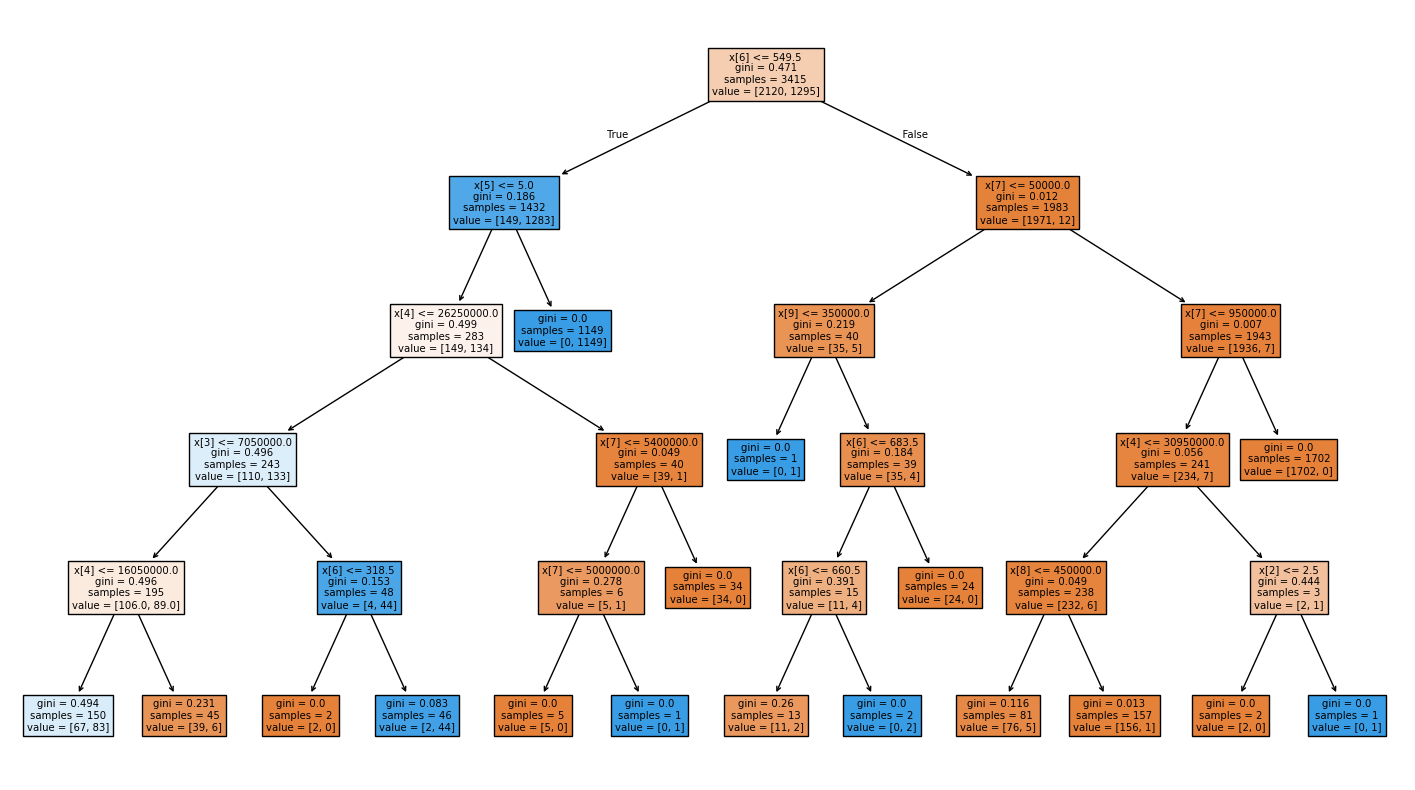

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(dtc, filled=True)

plt.show()